Pipeline с защитой от утечки




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score,
    recall_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

SEED = 42


---
 Загрузка данных и формирование Train/Test


In [2]:
df_train_raw = pd.read_csv('train.csv')
df_test_raw  = pd.read_csv('test.csv')

TARGET = 'satisfaction'

drop_cols = ['Unnamed: 0', 'id']
df_train_raw.drop(columns=[c for c in drop_cols if c in df_train_raw.columns], inplace=True)
df_test_raw.drop(columns=[c  for c in drop_cols if c in df_test_raw.columns],  inplace=True)

df_train_raw[TARGET] = (df_train_raw[TARGET] == 'satisfied').astype(int)
df_test_raw[TARGET]  = (df_test_raw[TARGET]  == 'satisfied').astype(int)

X_train = df_train_raw.drop(columns=[TARGET])
y_train = df_train_raw[TARGET]
X_test  = df_test_raw.drop(columns=[TARGET])
y_test  = df_test_raw[TARGET]

print(f"Train: {X_train.shape}   |   Test: {X_test.shape}")
print(f"\nБаланс классов (Train):")
print(y_train.value_counts(normalize=True).rename({0: 'Не доволен (0)', 1: 'Доволен (1)'}).to_string())
print(f"\nBaланс классов (Test):")
print(y_test.value_counts(normalize=True).rename({0: 'Не доволен (0)', 1: 'Доволен (1)'}).to_string())

Train: (103904, 22)   |   Test: (25976, 22)

Баланс классов (Train):
satisfaction
Не доволен (0)    0.566667
Доволен (1)       0.433333

Baланс классов (Test):
satisfaction
Не доволен (0)    0.561018
Доволен (1)       0.438982


---
 Определение групп признаков




In [3]:
numerical_features = [
    'Age',
    'Flight Distance',
    'Departure Delay in Minutes',
    'Arrival Delay in Minutes'
]

categorical_features = [
    'Gender',
    'Customer Type',
    'Type of Travel',
    'Class'
]

service_features = [
    'Inflight wifi service',
    'Departure/Arrival time convenient',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

all_features = numerical_features + categorical_features + service_features

print(f"Числовые признаки    : {len(numerical_features)}")
print(f"Категориальные       : {len(categorical_features)}")
print(f"Сервисные шкалы (0–5): {len(service_features)}")
print(f"Итого признаков      : {len(all_features)}")
print(f"\nПроверка покрытия колонок: {set(all_features) - set(X_train.columns)}")

Числовые признаки    : 4
Категориальные       : 4
Сервисные шкалы (0–5): 14
Итого признаков      : 22

Проверка покрытия колонок: set()


---
 Построение суб-пайплайнов предобработки



In [4]:
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   
    ('scaler',  StandardScaler())                    
], verbose=False)

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        drop='first',           
        handle_unknown='ignore',
        sparse_output=False
    ))
], verbose=False)


service_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  
    ('scaler',  StandardScaler())
], verbose=False)

print(f"  numerical_pipeline  : {[s[0] for s in numerical_pipeline.steps]}")
print(f"  categorical_pipeline: {[s[0] for s in categorical_pipeline.steps]}")
print(f"  service_pipeline    : {[s[0] for s in service_pipeline.steps]}")

  numerical_pipeline  : ['imputer', 'scaler']
  categorical_pipeline: ['imputer', 'encoder']
  service_pipeline    : ['imputer', 'scaler']


---
Сборка ColumnTransformer

`ColumnTransformer` маршрутизирует каждую группу признаков в нужный пайплайн  
и собирает результат в единую матрицу.  


In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline,    numerical_features),
        ('cat', categorical_pipeline,  categorical_features),
        ('svc', service_pipeline,      service_features)
    ],
    remainder='drop',               
    verbose_feature_names_out=True  
)

print(f"   Трансформеров: {len(preprocessor.transformers)}")
print(f"   Входных признаков: {len(all_features)}")

   Трансформеров: 3
   Входных признаков: 22


---
Финальный Pipeline: Preprocessor + Logistic Regression (L1)



In [6]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l1',               
        C=1.0,                      
        solver='liblinear',         
        max_iter=1000,              
        class_weight='balanced',    
        random_state=SEED
    ))
])

for name, step in baseline_pipeline.steps:
    print(f"   [{name}] → {type(step).__name__}")

   [preprocessor] → ColumnTransformer
   [classifier] → LogisticRegression


---
Stratified K-Fold Cross-Validation 5 фолдов



In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    'f1':        'f1',
    'roc_auc':   'roc_auc',
    'precision': 'precision',
    'recall':    'recall',
    'accuracy':  'accuracy'
}


cv_results = cross_validate(
    baseline_pipeline,
    X_train, y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
    error_score='raise'
)


cv_df = pd.DataFrame({
    'Fold':            range(1, 6),
    'Train F1':        cv_results['train_f1'],
    'Val F1':          cv_results['test_f1'],
    'Train ROC-AUC':   cv_results['train_roc_auc'],
    'Val ROC-AUC':     cv_results['test_roc_auc'],
    'Val Precision':   cv_results['test_precision'],
    'Val Recall':      cv_results['test_recall'],
    'Val Accuracy':    cv_results['test_accuracy']
}).set_index('Fold')

means = cv_df.mean().rename('Mean')
stds  = cv_df.std().rename('Std')
summary_row = pd.DataFrame(
    {col: [f"{means[col]:.4f} ± {stds[col]:.4f}"] for col in cv_df.columns},
    index=['Mean ± Std']
)


display(cv_df.round(4))
display(summary_row)

,Train F1,Val F1,Train ROC-AUC,Val ROC-AUC,Val Precision,Val Recall,Val Accuracy
Fold,,,,,,,
1,0.8501,0.8534,0.9270,0.9258,0.8517,0.8552,0.8727
2,0.8514,0.8463,0.9273,0.9244,0.8377,0.8551,0.8654
3,0.8499,0.8519,0.9263,0.9286,0.8408,0.8633,0.8699
4,0.8504,0.8508,0.9262,0.9292,0.8426,0.8592,0.8694
5,0.8505,0.8494,0.9270,0.9252,0.8443,0.8546,0.8687


,Train F1,Val F1,Train ROC-AUC,Val ROC-AUC,Val Precision,Val Recall,Val Accuracy
Mean ± Std,0.8505 ± 0.0006,0.8504 ± 0.0027,0.9268 ± 0.0005,0.9267 ± 0.0021,0.8434 ± 0.0052,0.8575 ± 0.0037,0.8692 ± 0.0026


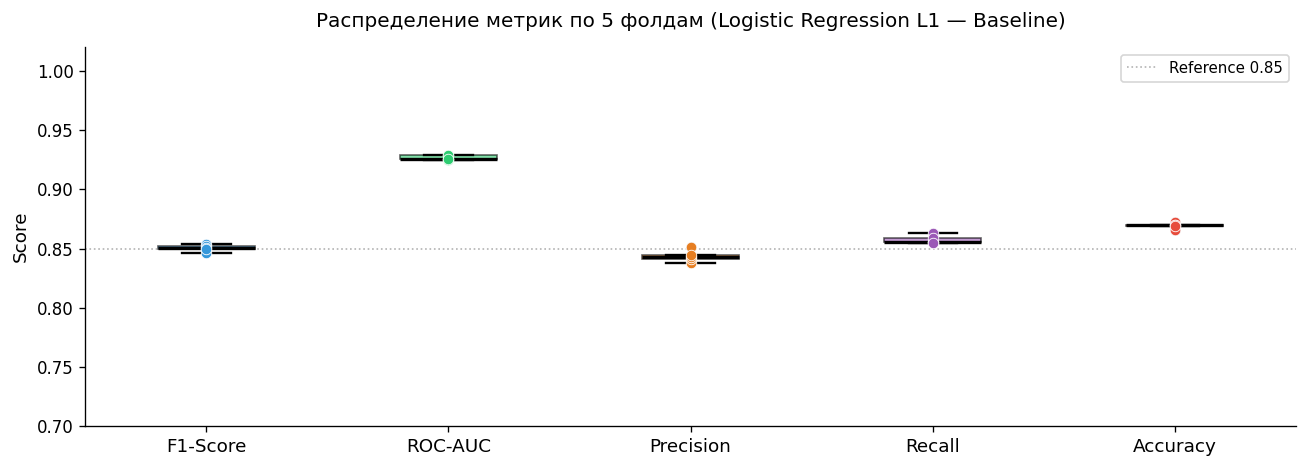

In [8]:
val_metrics = {
    'F1-Score':   cv_results['test_f1'],
    'ROC-AUC':    cv_results['test_roc_auc'],
    'Precision':  cv_results['test_precision'],
    'Recall':     cv_results['test_recall'],
    'Accuracy':   cv_results['test_accuracy']
}

fig, ax = plt.subplots(figsize=(11, 4))

palette = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']
positions = np.arange(len(val_metrics))

for i, (metric, values) in enumerate(val_metrics.items()):
    bp = ax.boxplot(
        values, positions=[i], widths=0.4,
        patch_artist=True, notch=False,
        boxprops=dict(facecolor=palette[i], alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4),
        flierprops=dict(marker='o', markersize=5)
    )
    ax.scatter([i] * len(values), values,
               color=palette[i], s=40, zorder=5, edgecolors='white', linewidths=0.5)

ax.set_xticks(positions)
ax.set_xticklabels(val_metrics.keys(), fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0.70, 1.02)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_title('Распределение метрик по 5 фолдам (Logistic Regression L1 — Baseline)', fontsize=12, pad=12)
ax.axhline(0.85, color='gray', linestyle=':', linewidth=1, alpha=0.6, label='Reference 0.85')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('cv_metrics_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
 Обучение на полных Train-данных и предсказание на Test

In [9]:
baseline_pipeline.fit(X_train, y_train)

y_pred       = baseline_pipeline.predict(X_test)
y_pred_proba = baseline_pipeline.predict_proba(X_test)[:, 1] 

print(f"Тестовая выборка: {X_test.shape[0]} наблюдений")
print(f"Предсказано 'Доволен'     : {y_pred.sum()}  ({y_pred.mean()*100:.1f}%)")
print(f"Предсказано 'Не доволен'  : {(1-y_pred).sum()}  ({(1-y_pred).mean()*100:.1f}%)")

Тестовая выборка: 25976 наблюдений
Предсказано 'Доволен'     : 11570  (44.5%)
Предсказано 'Не доволен'  : 14406  (55.5%)


---
Метрики качества на тестовой выборке

In [10]:
test_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_pred_proba),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred)
}


print("  МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ")

for name, val in test_metrics.items():
    bar = '█' * int(val * 25)
    print(f"  {name:12s}: {val:.4f}  {bar}")

print("  CLASSIFICATION REPORT")
print(classification_report(
    y_test, y_pred,
    target_names=['Не доволен (0)', 'Доволен (1)'],
    digits=4
))

  МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ
  Accuracy    : 0.8664  █████████████████████
  F1-Score    : 0.8489  █████████████████████
  ROC-AUC     : 0.9257  ███████████████████████
  Precision   : 0.8428  █████████████████████
  Recall      : 0.8551  █████████████████████
  CLASSIFICATION REPORT
                precision    recall  f1-score   support

Не доволен (0)     0.8853    0.8752    0.8802     14573
   Доволен (1)     0.8428    0.8551    0.8489     11403

      accuracy                         0.8664     25976
     macro avg     0.8641    0.8652    0.8646     25976
  weighted avg     0.8667    0.8664    0.8665     25976



---
Матрица ошибок (Confusion Matrix)

True Negatives  (TN):  12754  — верно: клиент НЕ доволен, модель предсказала НЕ доволен
False Positives (FP):   1819  Джорно выпил чай(это не чай)  — клиент НЕ доволен, модель предсказала ДОВОЛЕН
False Negatives (FN):   1652  Джорно выпил чай(это не чай)  — клиент ДОВОЛЕН, модель предсказала НЕ доволен
True Positives  (TP):   9751  — верно: клиент ДОВОЛЕН, модель предсказала ДОВОЛЕН


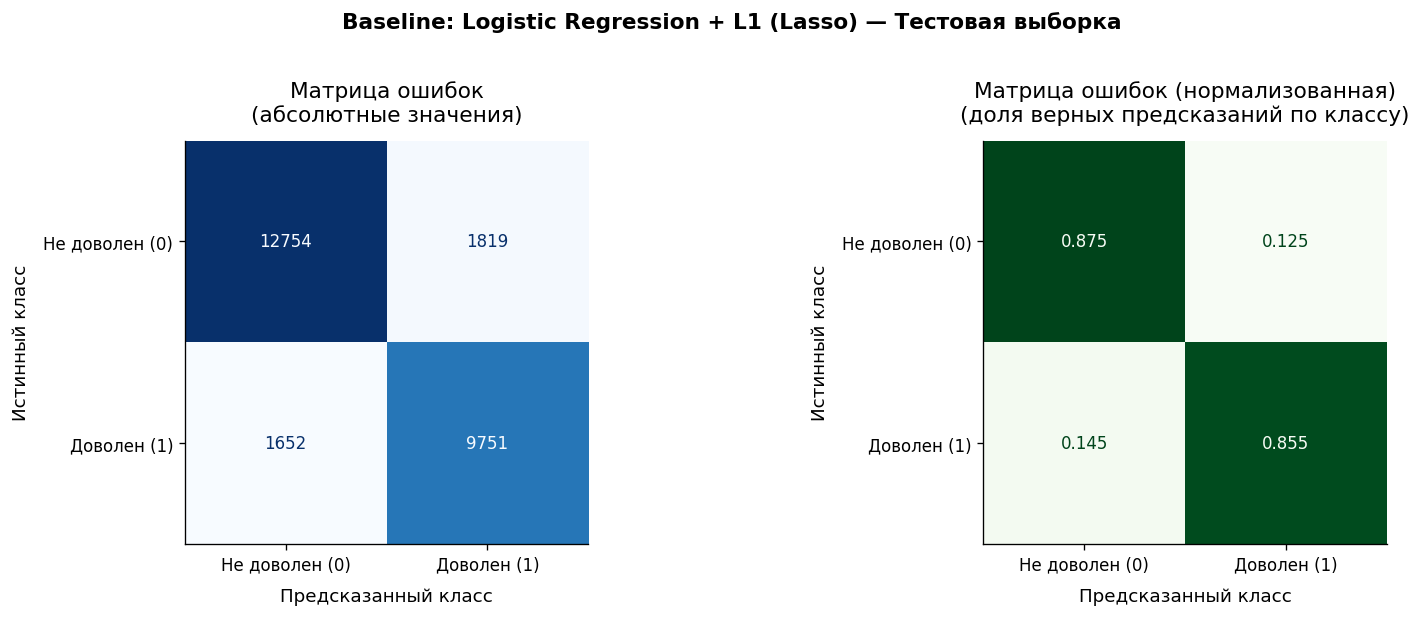

In [11]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print(f"True Negatives  (TN): {TN:>6}  — верно: клиент НЕ доволен, модель предсказала НЕ доволен")
print(f"False Positives (FP): {FP:>6}  Джорно выпил чай(это не чай)  — клиент НЕ доволен, модель предсказала ДОВОЛЕН")
print(f"False Negatives (FN): {FN:>6}  Джорно выпил чай(это не чай)  — клиент ДОВОЛЕН, модель предсказала НЕ доволен")
print(f"True Positives  (TP): {TP:>6}  — верно: клиент ДОВОЛЕН, модель предсказала ДОВОЛЕН")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp_abs = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Не доволен (0)', 'Доволен (1)']
)
disp_abs.plot(cmap='Blues', ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title('Матрица ошибок\n(абсолютные значения)', pad=12)
axes[0].set_xlabel('Предсказанный класс', labelpad=8)
axes[0].set_ylabel('Истинный класс', labelpad=8)

cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['Не доволен (0)', 'Доволен (1)']
)
disp_norm.plot(cmap='Greens', ax=axes[1], colorbar=False, values_format='.3f')
axes[1].set_title('Матрица ошибок (нормализованная)\n(доля верных предсказаний по классу)', pad=12)
axes[1].set_xlabel('Предсказанный класс', labelpad=8)
axes[1].set_ylabel('Истинный класс', labelpad=8)

plt.suptitle(
    'Baseline: Logistic Regression + L1 (Lasso) — Тестовая выборка',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

---
Анализ коэффициентов: что Lasso обнулила

  ЭФФЕКТ LASSO-РЕГУЛЯРИЗАЦИИ
  Всего признаков после OHE: 23
  Ненулевых коэффициентов  : 23
  Зануленных (Lasso)       : 0  ← автоматический feature selection


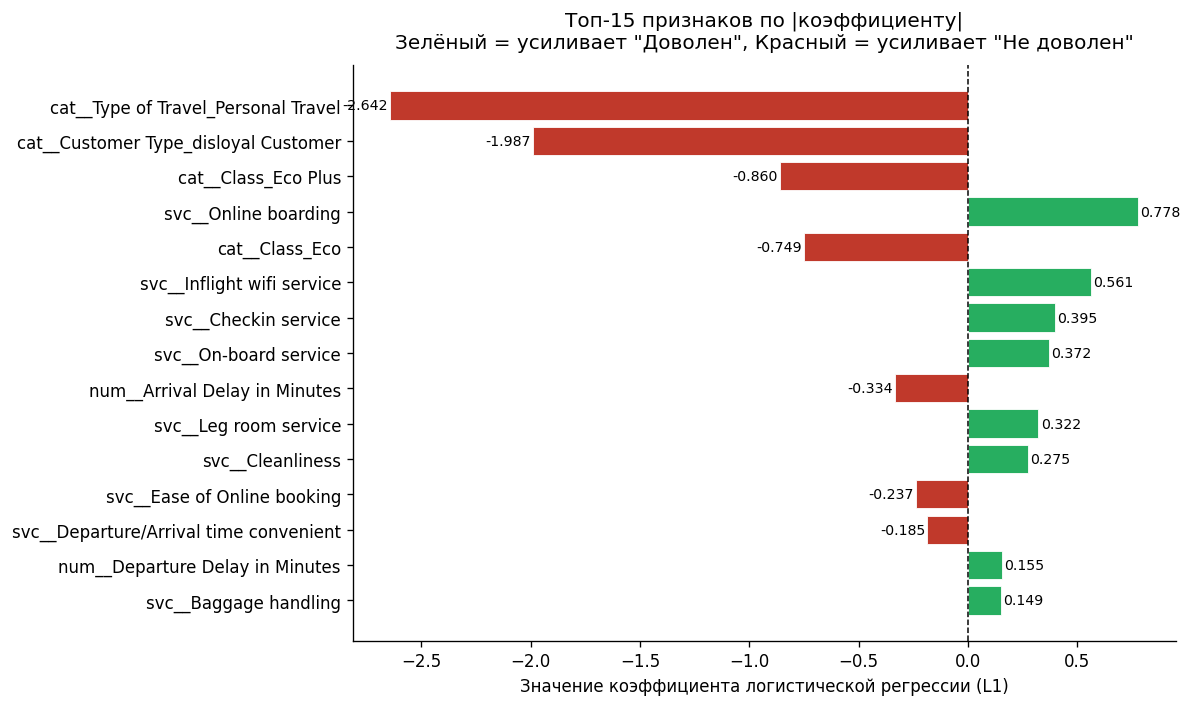

In [12]:
feature_names = baseline_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients  = baseline_pipeline.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefficients
}).assign(AbsCoef=lambda df: df['Coefficient'].abs())

zeroed_count   = (coef_df['Coefficient'] == 0).sum()
nonzero_count  = (coef_df['Coefficient'] != 0).sum()

print("  ЭФФЕКТ LASSO-РЕГУЛЯРИЗАЦИИ")
print(f"  Всего признаков после OHE: {len(coef_df)}")
print(f"  Ненулевых коэффициентов  : {nonzero_count}")
print(f"  Зануленных (Lasso)       : {zeroed_count}  ← автоматический feature selection")

if zeroed_count > 0:
    print("\n  Зануленные признаки:")
    print(coef_df.loc[coef_df['Coefficient'] == 0, 'Feature'].to_string(index=False))

top15 = coef_df.nlargest(15, 'AbsCoef')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#27ae60' if c > 0 else '#c0392b' for c in top15['Coefficient']]
bars   = ax.barh(top15['Feature'][::-1], top15['Coefficient'][::-1],
                 color=colors[::-1], edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.9, linestyle='--')

for bar, val in zip(bars, top15['Coefficient'][::-1]):
    offset = 0.01 if val >= 0 else -0.01
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8.5)

ax.set_title(
    'Топ-15 признаков по |коэффициенту|\n'
    'Зелёный = усиливает "Доволен", Красный = усиливает "Не доволен"',
    fontsize=12, pad=10
)
ax.set_xlabel('Значение коэффициента логистической регрессии (L1)', fontsize=10)
plt.tight_layout()
plt.savefig('feature_coefficients_l1.png', dpi=150, bbox_inches='tight')
plt.show()

---
 Сводная таблица: CV vs Test

In [14]:
summary = pd.DataFrame({
    'Метрика':         ['F1-Score', 'ROC-AUC', 'Precision', 'Recall', 'Accuracy'],
    'CV Mean (Val)':   [
        cv_results['test_f1'].mean(),
        cv_results['test_roc_auc'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_accuracy'].mean()
    ],
    'CV Std (Val)': [
        cv_results['test_f1'].std(),
        cv_results['test_roc_auc'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_accuracy'].std()
    ],
    'Test Score': [
        test_metrics['F1-Score'],
        test_metrics['ROC-AUC'],
        test_metrics['Precision'],
        test_metrics['Recall'],
        test_metrics['Accuracy']
    ]
}).set_index('Метрика').round(4)

summary['Gap (CV-Test)'] = (summary['CV Mean (Val)'] - summary['Test Score']).round(4)

print("  СВОДНАЯ ТАБЛИЦА: КРОСС-ВАЛИДАЦИЯ vs ТЕСТ")
display(summary.style
    .background_gradient(cmap='RdYlGn', subset=['Test Score'], vmin=0.7, vmax=1.0)
    .format({
        'CV Mean (Val)':   '{:.4f}',
        'CV Std (Val)':    '±{:.4f}',
        'Test Score':      '{:.4f}',
        'Gap (CV-Test)':   '{:+.4f}'
    })
)

  СВОДНАЯ ТАБЛИЦА: КРОСС-ВАЛИДАЦИЯ vs ТЕСТ


,CV Mean (Val),CV Std (Val),Test Score,Gap (CV-Test)
Метрика,,,,
F1-Score,0.8504,±0.0024,0.8489,+0.0015
ROC-AUC,0.9267,±0.0019,0.9257,+0.0010
Precision,0.8434,±0.0047,0.8428,+0.0006
Recall,0.8575,±0.0033,0.8551,+0.0024
Accuracy,0.8692,±0.0023,0.8664,+0.0028
